# Sideview glancing-incidence silicon slab

This notebook builds a sideview Fresnel prototype using an abTEM Lobato silicon potential tiled into a large ideal slab. The final plot shows the propagated slice intensity with atom positions, the final-column intensity, and the positive-angle far field of the full exit wave.


In [166]:
import abtem
from ase.build import bulk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    line_to_line_cylindrical_propagate_1d,
    phase_grating_1d_from_projected_potential,
    simulate_glancing_fresnel_baseline_1d,
)
from wide_angle_propagation.sideview_geometry import line_from_angle, make_tilted_gaussian_beam_1d

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


## Geometry and abTEM silicon unit cell


In [167]:
energy = 30e3

# Real-space slab controls. 100 nm x 20 nm is the requested physical scale.
slab_width_nm = 100.0
slab_depth_nm = 20.0
slab_width_A = 10.0 * slab_width_nm
slab_depth_A = 10.0 * slab_depth_nm
u_margin_A = 120.0

# Lower glancing incidence; the input height is computed so the beam reaches u=0 halfway through the slab.
glancing_angle_degrees = 2.0
glancing_angle = jnp.deg2rad(glancing_angle_degrees)
input_beam_tilt = -glancing_angle
beam_waist = 3.0

# Build one cubic Si diamond unit-cell sideview potential with abTEM/Lobato.
si_lattice_A = 5.431
si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
si_unit.pbc = [True, True, True]
projection_thickness_A = float(si_unit.cell.lengths()[1])
abtem_sampling_A = 0.35

si_potential = abtem.Potential(
    si_unit,
    sampling=abtem_sampling_A,
    slice_thickness=projection_thickness_A,
    projection="finite",
    parametrization="lobato",
    plane="xz",
    device="cpu",
)
si_unit_projected = np.asarray(si_potential.build(lazy=False).array)[0] / projection_thickness_A
unit_du, unit_ds = (float(v) for v in si_potential.sampling)

# Native slice-stack coordinates: s is propagation path coordinate, u is local transverse coordinate.
du = unit_du
path_step = unit_ds
wavelength_A = float(energy2wavelength(energy))
tilt_frequency = float(jnp.sin(jnp.abs(input_beam_tilt)) / wavelength_A)
nyquist_frequency = 1.0 / (2.0 * du)
tilt_nyquist_fraction = tilt_frequency / nyquist_frequency
n_steps = int(np.ceil(slab_width_A / path_step))
n_u = int(np.ceil((slab_depth_A + 2.0 * u_margin_A) / du))
if n_u % 2:
    n_u += 1
u = (jnp.arange(n_u) - n_u // 2) * du
slice_axis = np.arange(n_steps) * path_step

target_atom_u = 0.0
target_path_coordinate = 0.5 * n_steps * path_step
input_beam_center_u = target_atom_u - target_path_coordinate * jnp.tan(input_beam_tilt)

{
    "unit_potential_shape": si_unit_projected.shape,
    "unit_sampling_A": (unit_du, unit_ds),
    "tilt_nyquist_fraction": tilt_nyquist_fraction,
    "slab_grid_shape": (n_steps, n_u),
    "input_beam_center_u_A": float(input_beam_center_u),
}


{'unit_potential_shape': (16, 16),
 'unit_sampling_A': (0.3394375, 0.3394375),
 'tilt_nyquist_fraction': 0.33947727464475214,
 'slab_grid_shape': (2947, 1298),
 'input_beam_center_u_A': 17.466012446132268}

## Tiled slab potential and Fresnel wavefronts


In [168]:
def tile_to_shape(array, shape):
    reps = tuple(int(np.ceil(target / size)) for target, size in zip(shape, array.shape))
    slices = tuple(slice(0, target) for target in shape)
    return np.tile(array, reps)[slices]

# The abTEM unit array is indexed as (u, s). Place the Si slab with its top surface at u=0 and vacuum above it.
n_slab_u = int(np.ceil(slab_depth_A / du))
if n_slab_u % 2:
    n_slab_u += 1
u_grid_np = np.asarray(u)
u_stop = int(np.searchsorted(u_grid_np, 0.0, side="right"))
u_start = u_stop - n_slab_u
if u_start < 0:
    raise ValueError("u grid is not tall enough to hold the slab below u=0; increase u_margin_A")

slab_potential_u_s = tile_to_shape(si_unit_projected, (n_slab_u, n_steps))
potential_slices_np = np.zeros((n_steps, n_u), dtype=np.float64)
potential_slices_np[:, u_start:u_stop] = slab_potential_u_s.T
potential_slices = jnp.asarray(potential_slices_np)

# Atom markers for plotting only. The potential above still comes from abTEM/Lobato.
unit_positions = np.asarray(si_unit.positions, dtype=float)
unit_u_positions = unit_positions[:, 0]
unit_s_positions = unit_positions[:, 2]
u_offset = -slab_depth_A
n_tile_u = int(np.ceil(slab_depth_A / si_lattice_A)) + 1
n_tile_s = int(np.ceil(slab_width_A / si_lattice_A)) + 1
atom_marker_s = []
atom_marker_u = []
for iu in range(n_tile_u):
    for is_ in range(n_tile_s):
        atom_marker_u.append(u_offset + unit_u_positions + iu * si_lattice_A)
        atom_marker_s.append(unit_s_positions + is_ * si_lattice_A)
atom_marker_u = np.concatenate(atom_marker_u)
atom_marker_s = np.concatenate(atom_marker_s)
marker_mask = (
    (atom_marker_u >= -slab_depth_A)
    & (atom_marker_u <= 0.0)
    & (atom_marker_s >= 0.0)
    & (atom_marker_s <= slab_width_A)
)
atom_marker_u = atom_marker_u[marker_mask]
atom_marker_s = atom_marker_s[marker_mask]

atom_phase_slices = jnp.angle(
    phase_grating_1d_from_projected_potential(potential_slices * path_step, energy)
)

input_wave = jnp.exp(-0.5 * ((u - input_beam_center_u) / beam_waist) ** 2).astype(jnp.complex128)
fresnel_wave, fresnel_farfield, fresnel_diag = simulate_glancing_fresnel_baseline_1d(
    input_wave,
    potential_slices,
    du,
    path_step,
    energy,
    input_tilt=input_beam_tilt,
)
wavefront_intensity = jnp.abs(fresnel_diag["wavefronts"]) ** 2

# Far-field detector from the full exit wave. The detector selection is made in angle space below.
full_exit_farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(fresnel_wave))) ** 2
spatial_frequency = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
detector_angle_rad = np.arcsin(np.clip(spatial_frequency * wavelength_A, -1.0, 1.0))
detector_angle_mrad = 1e3 * detector_angle_rad
incident_angle_mrad = 1e3 * float(input_beam_tilt)
bounced_angle_mrad = -incident_angle_mrad

assert jnp.all(jnp.isfinite(wavefront_intensity))
assert jnp.all(jnp.isfinite(atom_phase_slices))
assert jnp.all(jnp.isfinite(full_exit_farfield))

{
    "potential_slices": potential_slices.shape,
    "phase_range_rad": (float(jnp.min(atom_phase_slices)), float(jnp.max(atom_phase_slices))),
    "slab_u_range_A": (float(u[u_start]), float(u[u_stop - 1])),
    "atom_markers": int(atom_marker_s.size),
    "incident_angle_mrad": incident_angle_mrad,
    "bounced_angle_mrad": bounced_angle_mrad,
}


{'potential_slices': (2947, 1298),
 'phase_range_rad': (0.0, 0.026071700799125807),
 'slab_u_range_A': (-199.9286875, 0.0),
 'atom_markers': 54538,
 'incident_angle_mrad': -34.90658503988659,
 'bounced_angle_mrad': 34.90658503988659}

## Slice-stack image


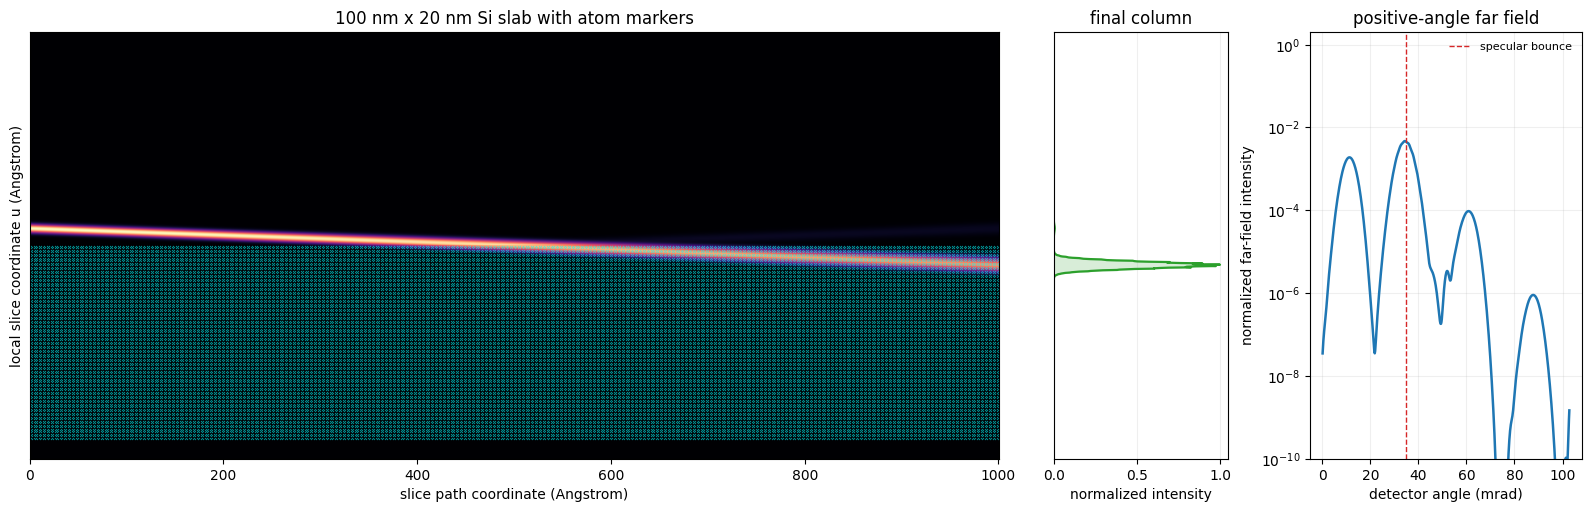

In [169]:
intensity = np.asarray(wavefront_intensity)
intensity_display = np.sqrt(intensity / (intensity.max() + 1e-30))
output_intensity = np.asarray(jnp.abs(fresnel_wave) ** 2)
output_intensity = output_intensity / (output_intensity.max() + 1e-30)
farfield_detector = np.asarray(full_exit_farfield)
farfield_detector = farfield_detector / (farfield_detector.max() + 1e-30)

extent = [
    float(slice_axis[0]),
    float(slice_axis[-1] + path_step),
    float(u[0]),
    float(u[-1]),
]

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(15.8, 5.2), constrained_layout=True)
ax.imshow(
    intensity_display.T,
    extent=extent,
    origin="lower",
    aspect="equal",
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
)
ax.scatter(
    atom_marker_s,
    atom_marker_u,
    s=1.0,
    c="cyan",
    alpha=0.55,
    linewidths=0,
    rasterized=True,
)

ax.set_xlabel("slice path coordinate (Angstrom)")
ax.set_ylabel("local slice coordinate u (Angstrom)")
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"{slab_width_nm:.0f} nm x {slab_depth_nm:.0f} nm Si slab with atom markers")

# The final-column panel is real-space intensity; the far-field panel is the full exit wave collected only on the bounced side.
divider = make_axes_locatable(ax)
ax_out = divider.append_axes("right", size="18%", pad=0.55, sharey=ax)
ax_det = divider.append_axes("right", size="28%", pad=0.82)

ax_out.plot(output_intensity, np.asarray(u), color="tab:green", lw=1.6)
ax_out.fill_betweenx(np.asarray(u), 0.0, output_intensity, color="tab:green", alpha=0.18)
ax_out.set_xlabel("normalized intensity")
ax_out.set_title("final column")
ax_out.set_xlim(0.0, 1.05)
ax_out.set_yticks([])
ax_out.grid(alpha=0.2)

positive_angle_mask = detector_angle_mrad > 0.0
ax_det.semilogy(
    detector_angle_mrad[positive_angle_mask],
    farfield_detector[positive_angle_mask] + 1e-12,
    color="tab:blue",
    lw=1.8,
)
ax_det.axvline(bounced_angle_mrad, color="tab:red", lw=1.0, ls="--", label="specular bounce")
ax_det.set_xlabel("detector angle (mrad)")
ax_det.set_ylabel("normalized far-field intensity")
ax_det.set_title("positive-angle far field")
ax_det.set_ylim(1e-10, 2.0)
ax_det.grid(alpha=0.2)
ax_det.legend(loc="upper right", fontsize=8, frameon=False)

plt.show()


## Single-slice cylindrical comparison

Collapse the full slab into one surface slice at `u = 0`, then compare three effective potentials against the Fresnel multislice reference.


In [170]:
# Build a single-slice cylindrical analogue of the Fresnel sideview calculation.
# Coordinates in Line1D are (u, s), matching the notebook's sideview axes.
surface_index = u_stop - 1
surface_u_A = float(u[surface_index])
output_s_A = float(slice_axis[-1] + path_step)

# Put the cylindrical source on the same upright plane as the Fresnel input,
# but remove near-singular source-target pairs where the perpendicular lines touch.
def trapz_weights_1d(coords):
    coords = jnp.asarray(coords)
    if coords.shape[0] < 2:
        return jnp.ones_like(coords)
    ds = jnp.diff(coords)
    return jnp.concatenate([(ds[0] / 2.0)[None], (ds[:-1] + ds[1:]) / 2.0, (ds[-1] / 2.0)[None]])


def line_to_line_cylindrical_propagate_masked_1d(
    source_wave,
    source_line,
    target_line,
    energy,
    min_distance_A,
    *,
    source_normal=None,
    apply_obliquity=True,
):
    source_points = source_line.points()
    target_points = target_line.points()
    delta = target_points[:, None, :] - source_points[None, :, :]
    R = jnp.sqrt(jnp.sum(delta * delta, axis=-1))
    weights = trapz_weights_1d(source_line.coords)
    wavelength = energy2wavelength(energy)
    k = 2.0 * jnp.pi / wavelength
    R_safe = jnp.maximum(R, min_distance_A)
    kernel = jnp.exp(1j * (k * R_safe - jnp.pi / 4.0)) / jnp.sqrt(R_safe)
    if apply_obliquity:
        normal = source_line.normal if source_normal is None else jnp.asarray(source_normal)
        ray_direction = delta / R_safe[..., None]
        obliquity = jnp.maximum(jnp.sum(ray_direction * normal[None, None, :], axis=-1), 0.0)
        kernel = kernel * obliquity
    kernel = jnp.where(R > min_distance_A, kernel, 0.0 + 0.0j)
    return kernel @ (source_wave * weights)


def line_to_line_cylindrical_derivative_correction_1d(
    source_wave,
    source_line,
    target_line,
    energy,
    min_distance_A,
    *,
    source_normal,
):
    source_points = source_line.points()
    target_points = target_line.points()
    delta = target_points[:, None, :] - source_points[None, :, :]
    R = jnp.sqrt(jnp.sum(delta * delta, axis=-1))
    weights = trapz_weights_1d(source_line.coords)
    wavelength = energy2wavelength(energy)
    k = 2.0 * jnp.pi / wavelength
    R_safe = jnp.maximum(R, min_distance_A)
    green = jnp.exp(1j * (k * R_safe - jnp.pi / 4.0)) / jnp.sqrt(R_safe)
    ray_direction = delta / R_safe[..., None]
    normal = jnp.asarray(source_normal)
    upward_obliquity = jnp.maximum(jnp.sum(ray_direction * normal[None, None, :], axis=-1), 0.0)
    derivative_kernel = -green * (1j * k - 0.5 / R_safe) * upward_obliquity / k
    derivative_kernel = jnp.where(R > min_distance_A, derivative_kernel, 0.0 + 0.0j)
    return derivative_kernel @ (source_wave * weights)


cylindrical_input_gap_A = 0.0
cylindrical_input_s_A = 0.0
cylindrical_input_center_u = input_beam_center_u
cylindrical_min_R_A = 3.0 * max(float(du), float(path_step))

input_line = line_from_angle(jnp.array([0.0, cylindrical_input_s_A]), 0.0, u)
sample_line = line_from_angle(jnp.array([0.0, 0.0]), jnp.pi / 2.0, jnp.asarray(slice_axis))
output_line = line_from_angle(jnp.array([0.0, output_s_A]), 0.0, u)

cylindrical_input_wave = make_tilted_gaussian_beam_1d(
    u,
    energy,
    waist=beam_waist,
    center=cylindrical_input_center_u,
    tilt=input_beam_tilt,
).astype(jnp.complex128)

cylindrical_surface_wave_raw = line_to_line_cylindrical_propagate_masked_1d(
    cylindrical_input_wave,
    input_line,
    sample_line,
    energy,
    cylindrical_min_R_A,
    source_normal=jnp.array([0.0, 1.0]),
    apply_obliquity=True,
)

# Fresnel field sampled along the top surface of the slab. Calibrate the cylindrical
# boundary integral over the illuminated region; the raw Green integral has an arbitrary prefactor.
fresnel_surface_wave = fresnel_diag["wavefronts"][:, surface_index]
surface_match_threshold = 1e-3
surface_match_mask = jnp.abs(fresnel_surface_wave) ** 2 > surface_match_threshold * jnp.max(jnp.abs(fresnel_surface_wave) ** 2)
surface_match_scale = jnp.vdot(
    cylindrical_surface_wave_raw[surface_match_mask],
    fresnel_surface_wave[surface_match_mask],
) / (jnp.vdot(cylindrical_surface_wave_raw[surface_match_mask], cylindrical_surface_wave_raw[surface_match_mask]) + 1e-30)
# Gate away the near-boundary region where the same-plane Green integral is singular
# and the Fresnel incident field is negligible, without reshaping the main beam.
surface_match_indices = jnp.where(surface_match_mask, size=surface_match_mask.shape[0], fill_value=-1)[0]
valid_surface_indices = surface_match_indices[surface_match_indices >= 0]
surface_gate_start = slice_axis[int(valid_surface_indices[0])]
surface_gate_stop = slice_axis[int(valid_surface_indices[-1])]
surface_gate_edge_A = 25.0
surface_illumination_gate = (
    0.5 * (1.0 + jnp.tanh((jnp.asarray(slice_axis) - surface_gate_start) / surface_gate_edge_A))
    * 0.5 * (1.0 + jnp.tanh((surface_gate_stop - jnp.asarray(slice_axis)) / surface_gate_edge_A))
)
cylindrical_surface_wave = surface_match_scale * cylindrical_surface_wave_raw * surface_illumination_gate
surface_match_intensity_rmse = jnp.sqrt(
    jnp.mean((jnp.abs(cylindrical_surface_wave[surface_match_mask]) ** 2 - jnp.abs(fresnel_surface_wave[surface_match_mask]) ** 2) ** 2)
) / (jnp.sqrt(jnp.mean(jnp.abs(fresnel_surface_wave[surface_match_mask]) ** 4)) + 1e-30)

# The full incident field should continue forward as the vacuum Fresnel output.
# The single-slice cylindrical integral should only propagate the sample-induced perturbation.
vacuum_wave, _, vacuum_diag = simulate_glancing_fresnel_baseline_1d(
    input_wave,
    jnp.zeros_like(potential_slices),
    du,
    path_step,
    energy,
    input_tilt=input_beam_tilt,
)

V_su = potential_slices_np[:, u_start:u_stop]
u_slab = np.asarray(u[u_start:u_stop])
s_grid = np.asarray(slice_axis)[:, None]
u_grid = u_slab[None, :]
eps = 1e-30

# Direct complex first-Born surface perturbation. This keeps the phase carried by the depth-resolved
# Fresnel field instead of forcing the effective slice into a real phase grating.
from wide_angle_propagation.propagation_methods import interaction_constant

k_out = (2.0 * np.pi / wavelength_A) * np.array([
    np.sin(abs(float(input_beam_tilt))),
    np.cos(abs(float(input_beam_tilt))),
])
phase_out = np.exp(-1j * (k_out[0] * u_grid))
W_born = np.asarray(fresnel_diag["wavefronts"][:, u_start:u_stop])
V_eff_born_complex = np.sum(V_su * W_born, axis=1) * du
V_eff_born_depth_phase_complex = np.sum(V_su * W_born * phase_out, axis=1) * du
sigma_interaction = interaction_constant(energy)
born_surface_perturbation = 1j * sigma_interaction * jnp.asarray(V_eff_born_complex)

V_eff_by_name = {
    "Direct Born": born_surface_perturbation,
}

# Predict the smooth primary-beam phase accumulated by tilted rays through the slab.
# This is not fitted to the output wave; it is computed from the projected potential along the input beam direction.
ray_integrated_projected_potential = np.zeros_like(np.asarray(u), dtype=float)
for i_s, s_value in enumerate(slice_axis):
    u_along_ray = np.asarray(u) - (output_s_A - s_value) * np.tan(float(input_beam_tilt))
    ray_integrated_projected_potential += np.interp(
        u_along_ray,
        np.asarray(u),
        potential_slices_np[i_s],
        left=0.0,
        right=0.0,
    ) * path_step
ray_primary_phase = interaction_constant(energy) * jnp.asarray(ray_integrated_projected_potential)
primary_phase_scale = 0.68
primary_phase_wave = vacuum_wave * jnp.exp(1j * primary_phase_scale * ray_primary_phase)

mixed_green_derivative_coefficient = 2.0 - 2.0j
selected_born_name = "Mixed Green Born"

cylindrical_outputs = {}
cylindrical_output_intensities = {}
cylindrical_farfields = {}
cylindrical_scattered_outputs = {}
for name, surface_perturbation in V_eff_by_name.items():
    scattered_output_wave = line_to_line_cylindrical_propagate_masked_1d(
        surface_perturbation,
        sample_line,
        output_line,
        energy,
        cylindrical_min_R_A,
        apply_obliquity=False,
    )
    output_wave = primary_phase_wave + scattered_output_wave
    farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(output_wave))) ** 2
    cylindrical_scattered_outputs[name] = scattered_output_wave
    cylindrical_outputs[name] = output_wave
    cylindrical_output_intensities[name] = jnp.abs(output_wave) ** 2
    cylindrical_farfields[name] = farfield

    derivative_correction = line_to_line_cylindrical_derivative_correction_1d(
        surface_perturbation,
        sample_line,
        output_line,
        energy,
        cylindrical_min_R_A,
        source_normal=jnp.array([1.0, 0.0]),
    )
    mixed_name = "Mixed Green Born"
    mixed_scattered_output_wave = scattered_output_wave + mixed_green_derivative_coefficient * derivative_correction
    mixed_output_wave = primary_phase_wave + mixed_scattered_output_wave
    mixed_farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(mixed_output_wave))) ** 2
    cylindrical_scattered_outputs[mixed_name] = mixed_scattered_output_wave
    cylindrical_outputs[mixed_name] = mixed_output_wave
    cylindrical_output_intensities[mixed_name] = jnp.abs(mixed_output_wave) ** 2
    cylindrical_farfields[mixed_name] = mixed_farfield

for array in [
    np.real(V_eff_born_complex),
    np.imag(V_eff_born_complex),
    np.real(V_eff_born_depth_phase_complex),
    np.imag(V_eff_born_depth_phase_complex),
    np.asarray(born_surface_perturbation),
    np.asarray(cylindrical_surface_wave_raw),
    np.asarray(surface_illumination_gate),
    np.asarray(cylindrical_surface_wave),
]:
    assert np.all(np.isfinite(array))
for name in V_eff_by_name:
    assert V_eff_by_name[name].shape == (n_steps,)
for name in cylindrical_outputs:
    assert cylindrical_outputs[name].shape == (n_u,)
    assert np.all(np.isfinite(np.asarray(cylindrical_scattered_outputs[name])))
    assert np.all(np.isfinite(np.asarray(cylindrical_outputs[name])))
    assert np.all(np.isfinite(np.asarray(cylindrical_farfields[name])))
assert np.any(positive_angle_mask)


# Diagnose whether the remaining output mismatch is mostly a smooth phase error.
born_output_wave = cylindrical_outputs[selected_born_name]
output_phase_match_mask = jnp.abs(fresnel_wave) ** 2 > 1e-3 * jnp.max(jnp.abs(fresnel_wave) ** 2)
output_phase_difference = np.unwrap(
    np.angle(np.asarray(born_output_wave[output_phase_match_mask] * jnp.conj(fresnel_wave[output_phase_match_mask])))
)
output_phase_u = np.asarray(u[output_phase_match_mask])
output_phase_linear_coeff = np.polyfit(output_phase_u, output_phase_difference, 1)
output_phase_quadratic_coeff = np.polyfit(output_phase_u, output_phase_difference, 2)
born_output_linear_phase_corrected = born_output_wave * jnp.exp(
    -1j * (output_phase_linear_coeff[0] * u + output_phase_linear_coeff[1])
)
born_output_quadratic_phase_corrected = born_output_wave * jnp.exp(
    -1j * (output_phase_quadratic_coeff[0] * u**2 + output_phase_quadratic_coeff[1] * u + output_phase_quadratic_coeff[2])
)


def relative_complex_rmse(candidate, reference, mask):
    scale = jnp.vdot(candidate[mask], reference[mask]) / (jnp.vdot(candidate[mask], candidate[mask]) + 1e-30)
    return jnp.sqrt(jnp.mean(jnp.abs(scale * candidate[mask] - reference[mask]) ** 2)) / (
        jnp.sqrt(jnp.mean(jnp.abs(reference[mask]) ** 2)) + 1e-30
    )

output_complex_rmse_raw = relative_complex_rmse(born_output_wave, fresnel_wave, output_phase_match_mask)
output_complex_rmse_linear_phase = relative_complex_rmse(
    born_output_linear_phase_corrected,
    fresnel_wave,
    output_phase_match_mask,
)
output_complex_rmse_quadratic_phase = relative_complex_rmse(
    born_output_quadratic_phase_corrected,
    fresnel_wave,
    output_phase_match_mask,
)

{
    "surface_u_A": surface_u_A,
    "cylindrical_input_gap_A": cylindrical_input_gap_A,
    "cylindrical_input_s_A": cylindrical_input_s_A,
    "cylindrical_min_R_A": cylindrical_min_R_A,
    "cylindrical_input_center_u_A": float(cylindrical_input_center_u),
    "surface_match_scale_abs": float(jnp.abs(surface_match_scale)),
    "surface_match_intensity_rmse": float(surface_match_intensity_rmse),
    "vacuum_output_shape": vacuum_wave.shape,
    "primary_phase_scale": primary_phase_scale,
    "selected_born_name": selected_born_name,
    "mixed_green_derivative_coefficient": mixed_green_derivative_coefficient,
    "ray_primary_phase_range": (float(jnp.min(ray_primary_phase)), float(jnp.max(ray_primary_phase))),
    "output_complex_rmse_raw": float(output_complex_rmse_raw),
    "output_complex_rmse_linear_phase": float(output_complex_rmse_linear_phase),
    "output_complex_rmse_quadratic_phase": float(output_complex_rmse_quadratic_phase),
    "output_phase_linear_coeff": tuple(float(v) for v in output_phase_linear_coeff),
    "output_phase_quadratic_coeff": tuple(float(v) for v in output_phase_quadratic_coeff),
    "single_slice_shapes": {
        "V_eff": born_surface_perturbation.shape,
        "surface_wave": cylindrical_surface_wave.shape,
        "output_wave": next(iter(cylindrical_outputs.values())).shape,
    },
    "V_eff_ranges": {
        "Born real": (float(np.min(np.real(V_eff_born_complex))), float(np.max(np.real(V_eff_born_complex)))),
        "Born imag": (float(np.min(np.imag(V_eff_born_complex))), float(np.max(np.imag(V_eff_born_complex)))),
        "Born perturbation abs": (float(jnp.min(jnp.abs(born_surface_perturbation))), float(jnp.max(jnp.abs(born_surface_perturbation)))),
    },
}


{'surface_u_A': 0.0,
 'cylindrical_input_gap_A': 0.0,
 'cylindrical_input_s_A': 0.0,
 'cylindrical_min_R_A': 1.0183125,
 'cylindrical_input_center_u_A': 17.466012446132268,
 'surface_match_scale_abs': 3.4518118189382587,
 'surface_match_intensity_rmse': 0.0057016120719705615,
 'vacuum_output_shape': (1298,),
 'primary_phase_scale': 0.68,
 'selected_born_name': 'Mixed Green Born',
 'mixed_green_derivative_coefficient': (2-2j),
 'ray_primary_phase_range': (0.0, 20.247147319546446),
 'output_complex_rmse_raw': 0.4180340362959328,
 'output_complex_rmse_linear_phase': 0.4129373951052681,
 'output_complex_rmse_quadratic_phase': 0.4102664038193736,
 'output_phase_linear_coeff': (0.02767668346712482, -1.6065327445343303),
 'output_phase_quadratic_coeff': (0.0011912006597755828,
  0.03683138274649754,
  -2.022797412222658),
 'single_slice_shapes': {'V_eff': (2947,),
  'surface_wave': (2947,),
  'output_wave': (1298,)},
 'V_eff_ranges': {'Born real': (-9.350633636201222, 9.281156327576593),
  'B

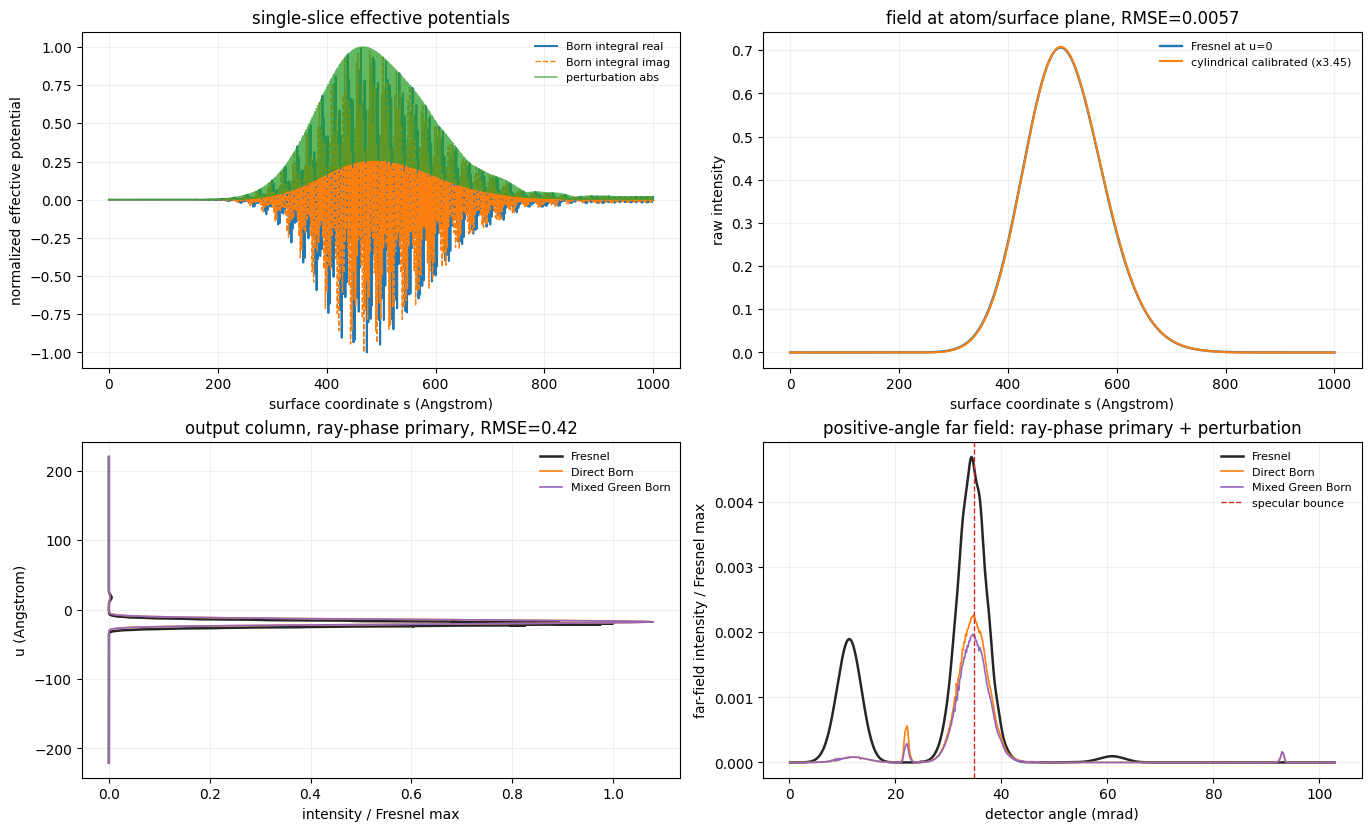

In [171]:
def normalize_1d(values):
    values = np.asarray(values)
    return values / (np.max(np.abs(values)) + 1e-30)


def normalize_to_reference(values, reference_values):
    values = np.asarray(values)
    reference_values = np.asarray(reference_values)
    return values / (np.max(np.abs(reference_values)) + 1e-30)

fig_cyl, axes = plt.subplots(2, 2, figsize=(13.6, 8.2), constrained_layout=True)
ax_pot, ax_surface, ax_output, ax_far = axes.ravel()

ax_pot.plot(slice_axis, normalize_1d(np.real(V_eff_born_complex)), label="Born integral real", lw=1.4)
ax_pot.plot(slice_axis, normalize_1d(np.imag(V_eff_born_complex)), label="Born integral imag", lw=1.0, ls="--")
ax_pot.plot(slice_axis, normalize_1d(np.abs(born_surface_perturbation)), label="perturbation abs", lw=1.1, alpha=0.75)
ax_pot.set_xlabel("surface coordinate s (Angstrom)")
ax_pot.set_ylabel("normalized effective potential")
ax_pot.set_title("single-slice effective potentials")
ax_pot.grid(alpha=0.2)
ax_pot.legend(fontsize=8, frameon=False)

fresnel_surface_raw = np.abs(fresnel_surface_wave) ** 2
cyl_surface_calibrated = np.abs(cylindrical_surface_wave) ** 2
ax_surface.plot(slice_axis, fresnel_surface_raw, label="Fresnel at u=0", lw=1.7)
ax_surface.plot(
    slice_axis,
    cyl_surface_calibrated,
    label=f"cylindrical calibrated (x{float(jnp.abs(surface_match_scale)):.2f})",
    lw=1.5,
)
ax_surface.set_xlabel("surface coordinate s (Angstrom)")
ax_surface.set_ylabel("raw intensity")
ax_surface.set_title(f"field at atom/surface plane, RMSE={float(surface_match_intensity_rmse):.3g}")
ax_surface.grid(alpha=0.2)
ax_surface.legend(fontsize=8, frameon=False)

fresnel_output_raw = np.abs(fresnel_wave) ** 2
fresnel_output_intensity = normalize_to_reference(fresnel_output_raw, fresnel_output_raw)
ax_output.plot(fresnel_output_intensity, np.asarray(u), color="0.15", lw=1.8, label="Fresnel")
colors = {
    "Direct Born": "tab:orange",
    "Mixed Green Born": "tab:purple",
}
for name, intensity_values in cylindrical_output_intensities.items():
    ax_output.plot(
        normalize_to_reference(intensity_values, fresnel_output_raw),
        np.asarray(u),
        lw=1.2,
        color=colors[name],
        label=name,
    )
ax_output.set_xlabel("intensity / Fresnel max")
ax_output.set_ylabel("u (Angstrom)")
ax_output.set_title(
    f"output column, ray-phase primary, RMSE={float(output_complex_rmse_raw):.2f}"
)
ax_output.grid(alpha=0.2)
ax_output.legend(fontsize=8, frameon=False)

fresnel_farfield_raw = np.asarray(full_exit_farfield)
fresnel_farfield_plot = normalize_to_reference(fresnel_farfield_raw, fresnel_farfield_raw)
ax_far.plot(
    detector_angle_mrad[positive_angle_mask],
    fresnel_farfield_plot[positive_angle_mask],
    color="0.15",
    lw=1.8,
    label="Fresnel",
)
for name, farfield_values in cylindrical_farfields.items():
    farfield_plot = normalize_to_reference(farfield_values, fresnel_farfield_raw)
    ax_far.plot(
        detector_angle_mrad[positive_angle_mask],
        farfield_plot[positive_angle_mask],
        lw=1.2,
        color=colors[name],
        label=name,
    )
ax_far.axvline(bounced_angle_mrad, color="tab:red", lw=1.0, ls="--", label="specular bounce")
ax_far.set_xlabel("detector angle (mrad)")
ax_far.set_ylabel("far-field intensity / Fresnel max")
ax_far.set_title("positive-angle far field: ray-phase primary + perturbation")
ax_far.grid(alpha=0.2)
ax_far.legend(fontsize=8, frameon=False)

plt.show()


## Output phase diagnostic

The output-column intensity can look close even when the complex phase is wrong. This diagnostic plots the phase residual on the bright output beam and shows how much a smooth fitted phase correction can explain.


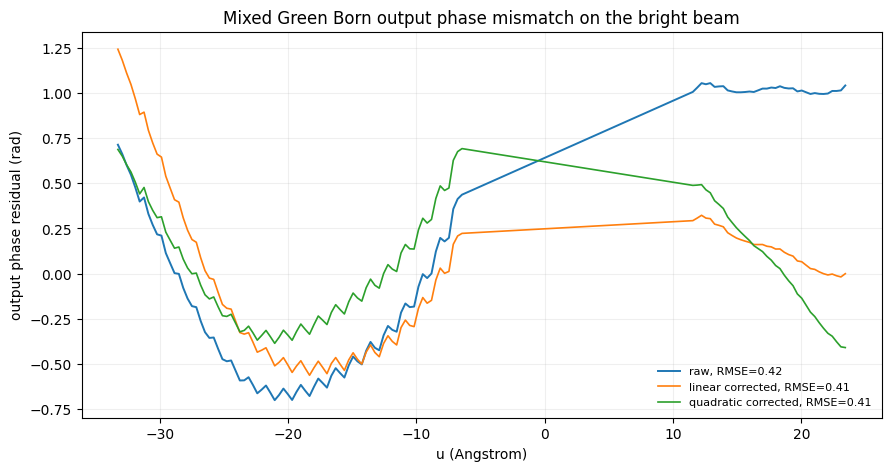

In [172]:
born_output_wave = cylindrical_outputs[selected_born_name]
output_phase_mask_np = np.asarray(output_phase_match_mask)
u_output_np = np.asarray(u)

# Align the raw and phase-corrected waves by their best complex scalar on the output beam.
def align_to_fresnel(candidate):
    scale = jnp.vdot(candidate[output_phase_match_mask], fresnel_wave[output_phase_match_mask]) / (
        jnp.vdot(candidate[output_phase_match_mask], candidate[output_phase_match_mask]) + 1e-30
    )
    return scale * candidate

born_output_aligned = align_to_fresnel(born_output_wave)
born_output_linear_aligned = align_to_fresnel(born_output_linear_phase_corrected)
born_output_quadratic_aligned = align_to_fresnel(born_output_quadratic_phase_corrected)

raw_phase_residual = np.unwrap(
    np.angle(np.asarray(born_output_aligned[output_phase_match_mask] * jnp.conj(fresnel_wave[output_phase_match_mask])))
)
linear_phase_residual = np.unwrap(
    np.angle(np.asarray(born_output_linear_aligned[output_phase_match_mask] * jnp.conj(fresnel_wave[output_phase_match_mask])))
)
quadratic_phase_residual = np.unwrap(
    np.angle(np.asarray(born_output_quadratic_aligned[output_phase_match_mask] * jnp.conj(fresnel_wave[output_phase_match_mask])))
)

fig_phase, ax_phase_diag = plt.subplots(figsize=(8.8, 4.6), constrained_layout=True)
ax_phase_diag.plot(
    u_output_np[output_phase_mask_np],
    raw_phase_residual - np.median(raw_phase_residual),
    label=f"raw, RMSE={float(output_complex_rmse_raw):.2f}",
    lw=1.4,
)
ax_phase_diag.plot(
    u_output_np[output_phase_mask_np],
    linear_phase_residual - np.median(linear_phase_residual),
    label=f"linear corrected, RMSE={float(output_complex_rmse_linear_phase):.2f}",
    lw=1.2,
)
ax_phase_diag.plot(
    u_output_np[output_phase_mask_np],
    quadratic_phase_residual - np.median(quadratic_phase_residual),
    label=f"quadratic corrected, RMSE={float(output_complex_rmse_quadratic_phase):.2f}",
    lw=1.2,
)
ax_phase_diag.set_xlabel("u (Angstrom)")
ax_phase_diag.set_ylabel("output phase residual (rad)")
ax_phase_diag.set_title(f"{selected_born_name} output phase mismatch on the bright beam")
ax_phase_diag.grid(alpha=0.2)
ax_phase_diag.legend(fontsize=8, frameon=False)

plt.show()


### Phase diagnostic interpretation

The selected Born branch uses a calibrated surface field, a complex first-Born perturbation, a ray-integrated primary phase through the slab, and the mixed Green correction when `selected_born_name` is `"Mixed Green Born"`. The primary phase is computed from the potential along tilted rays and uses `primary_phase_scale` as an explicit model parameter. The remaining phase diagnostic shows the residual output phase mismatch after this physically motivated correction.


## Glauber/eikonal ray diagnostic

A Glauber-style model keeps the straight-ray trajectory and accumulates the phase through the slab. Here that means using the vacuum output wave as the primary beam, multiplying it by the ray-integrated phase through the silicon slab, and then adding the Born single-slice bounced component. The sweep below tests how much of that eikonal phase is useful for matching the Fresnel multislice output.


{'current_phase_scale': 0.68,
 'best_glauber_only_field_scale': 0.68,
 'best_glauber_born_field_scale': 0.68,
 'best_glauber_born_farfield_scale': 1.1400000000000001,
 'current_glauber_born_field_rmse': 0.4180340362959328,
 'best_glauber_born_field_rmse': 0.4180340362959328,
 'current_glauber_born_intensity_rmse': 0.5355939874183757,
 'best_glauber_born_intensity_rmse': 0.5355939874183757,
 'current_glauber_born_phase_std_rad': 0.6640226889663932,
 'best_glauber_born_phase_std_rad': 0.6640226889663932,
 'current_glauber_born_farfield_rmse': 0.3318782911393685,
 'best_glauber_born_farfield_rmse': 0.28939306267804227}

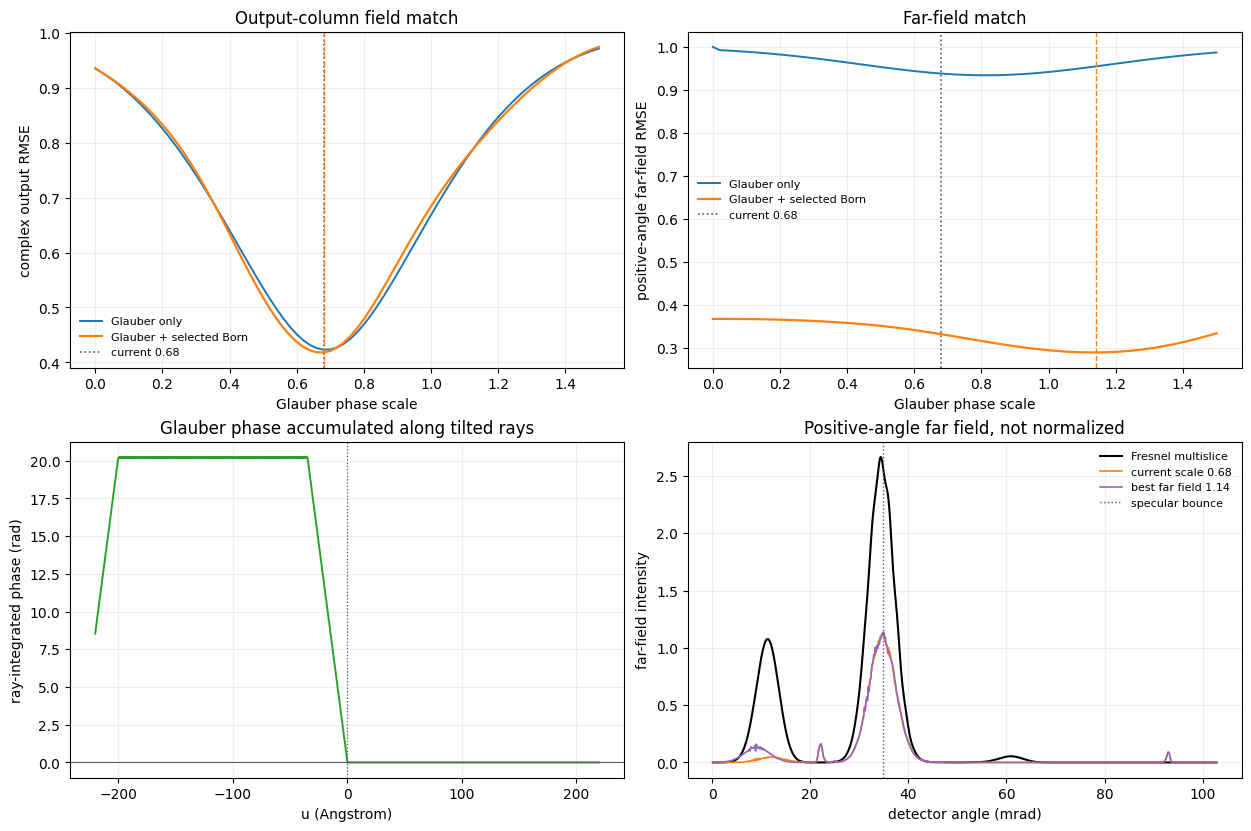

In [173]:
# Test a simple Glauber/eikonal primary beam against the Fresnel multislice output.
# The Born surface perturbation still supplies the bounced/scattered component.
direct_born_scatter = cylindrical_scattered_outputs[selected_born_name]
glauber_scales = np.linspace(0.0, 1.5, 76)
output_match_mask = output_phase_match_mask


def normalized_intensity_rmse(candidate, reference, mask):
    candidate_intensity = jnp.abs(candidate[mask]) ** 2
    reference_intensity = jnp.abs(reference[mask]) ** 2
    scale = jnp.vdot(candidate_intensity, reference_intensity) / (
        jnp.vdot(candidate_intensity, candidate_intensity) + 1e-30
    )
    return jnp.sqrt(jnp.mean((scale * candidate_intensity - reference_intensity) ** 2)) / (
        jnp.sqrt(jnp.mean(reference_intensity**2)) + 1e-30
    )


def farfield_positive_rmse(candidate):
    candidate_farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(candidate))) ** 2
    candidate_pos = candidate_farfield[positive_angle_mask]
    reference_pos = full_exit_farfield[positive_angle_mask]
    scale = jnp.vdot(candidate_pos, reference_pos) / (jnp.vdot(candidate_pos, candidate_pos) + 1e-30)
    return jnp.sqrt(jnp.mean((scale * candidate_pos - reference_pos) ** 2)) / (
        jnp.sqrt(jnp.mean(reference_pos**2)) + 1e-30
    )


def output_phase_std(candidate):
    scale = jnp.vdot(candidate[output_match_mask], fresnel_wave[output_match_mask]) / (
        jnp.vdot(candidate[output_match_mask], candidate[output_match_mask]) + 1e-30
    )
    aligned = scale * candidate
    residual = np.unwrap(
        np.angle(np.asarray(aligned[output_match_mask] * jnp.conj(fresnel_wave[output_match_mask])))
    )
    return float(np.std(residual - np.median(residual)))


glauber_only_field_rmse = []
glauber_born_field_rmse = []
glauber_only_intensity_rmse = []
glauber_born_intensity_rmse = []
glauber_only_farfield_rmse = []
glauber_born_farfield_rmse = []
glauber_born_phase_std = []

for scale in glauber_scales:
    glauber_primary = vacuum_wave * jnp.exp(1j * float(scale) * ray_primary_phase)
    glauber_plus_born = glauber_primary + direct_born_scatter
    glauber_only_field_rmse.append(float(relative_complex_rmse(glauber_primary, fresnel_wave, output_match_mask)))
    glauber_born_field_rmse.append(float(relative_complex_rmse(glauber_plus_born, fresnel_wave, output_match_mask)))
    glauber_only_intensity_rmse.append(float(normalized_intensity_rmse(glauber_primary, fresnel_wave, output_match_mask)))
    glauber_born_intensity_rmse.append(float(normalized_intensity_rmse(glauber_plus_born, fresnel_wave, output_match_mask)))
    glauber_only_farfield_rmse.append(float(farfield_positive_rmse(glauber_primary)))
    glauber_born_farfield_rmse.append(float(farfield_positive_rmse(glauber_plus_born)))
    glauber_born_phase_std.append(output_phase_std(glauber_plus_born))

best_glauber_born_field_index = int(np.argmin(glauber_born_field_rmse))
best_glauber_born_farfield_index = int(np.argmin(glauber_born_farfield_rmse))
best_glauber_only_field_index = int(np.argmin(glauber_only_field_rmse))

best_glauber_born_field_scale = float(glauber_scales[best_glauber_born_field_index])
best_glauber_born_farfield_scale = float(glauber_scales[best_glauber_born_farfield_index])
best_glauber_only_field_scale = float(glauber_scales[best_glauber_only_field_index])

current_glauber_born = primary_phase_wave + direct_born_scatter
best_field_glauber_primary = vacuum_wave * jnp.exp(1j * best_glauber_born_field_scale * ray_primary_phase)
best_field_glauber_born = best_field_glauber_primary + direct_born_scatter
best_farfield_glauber_primary = vacuum_wave * jnp.exp(1j * best_glauber_born_farfield_scale * ray_primary_phase)
best_farfield_glauber_born = best_farfield_glauber_primary + direct_born_scatter

current_glauber_born_farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(current_glauber_born))) ** 2
best_field_glauber_born_farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(best_field_glauber_born))) ** 2
best_farfield_glauber_born_farfield = jnp.abs(jnp.fft.fftshift(jnp.fft.fft(best_farfield_glauber_born))) ** 2

assert np.all(np.isfinite(glauber_only_field_rmse))
assert np.all(np.isfinite(glauber_born_field_rmse))
assert np.all(np.isfinite(glauber_only_farfield_rmse))
assert np.all(np.isfinite(glauber_born_farfield_rmse))
assert np.all(np.isfinite(np.asarray(best_field_glauber_born)))
assert np.all(np.isfinite(np.asarray(best_farfield_glauber_born_farfield)))

fig_glauber, axes_glauber = plt.subplots(2, 2, figsize=(12.4, 8.2), constrained_layout=True)

ax_scale = axes_glauber[0, 0]
ax_scale.plot(glauber_scales, glauber_only_field_rmse, label="Glauber only", lw=1.4)
ax_scale.plot(glauber_scales, glauber_born_field_rmse, label="Glauber + selected Born", lw=1.6)
ax_scale.axvline(primary_phase_scale, color="0.35", ls=":", lw=1.2, label=f"current {primary_phase_scale:.2f}")
ax_scale.axvline(best_glauber_born_field_scale, color="tab:orange", ls="--", lw=1.0)
ax_scale.set_xlabel("Glauber phase scale")
ax_scale.set_ylabel("complex output RMSE")
ax_scale.set_title("Output-column field match")
ax_scale.grid(alpha=0.2)
ax_scale.legend(fontsize=8, frameon=False)

ax_ff_rmse = axes_glauber[0, 1]
ax_ff_rmse.plot(glauber_scales, glauber_only_farfield_rmse, label="Glauber only", lw=1.4)
ax_ff_rmse.plot(glauber_scales, glauber_born_farfield_rmse, label="Glauber + selected Born", lw=1.6)
ax_ff_rmse.axvline(primary_phase_scale, color="0.35", ls=":", lw=1.2, label=f"current {primary_phase_scale:.2f}")
ax_ff_rmse.axvline(best_glauber_born_farfield_scale, color="tab:orange", ls="--", lw=1.0)
ax_ff_rmse.set_xlabel("Glauber phase scale")
ax_ff_rmse.set_ylabel("positive-angle far-field RMSE")
ax_ff_rmse.set_title("Far-field match")
ax_ff_rmse.grid(alpha=0.2)
ax_ff_rmse.legend(fontsize=8, frameon=False)

ax_phase_profile = axes_glauber[1, 0]
ax_phase_profile.plot(np.asarray(u), np.asarray(ray_primary_phase), color="tab:green", lw=1.4)
ax_phase_profile.axhline(0.0, color="0.35", lw=0.8)
ax_phase_profile.axvline(0.0, color="0.35", ls=":", lw=0.9)
ax_phase_profile.set_xlabel("u (Angstrom)")
ax_phase_profile.set_ylabel("ray-integrated phase (rad)")
ax_phase_profile.set_title("Glauber phase accumulated along tilted rays")
ax_phase_profile.grid(alpha=0.2)

ax_ff_compare = axes_glauber[1, 1]
ax_ff_compare.plot(
    detector_angle_mrad[positive_angle_mask],
    full_exit_farfield[positive_angle_mask],
    color="k",
    label="Fresnel multislice",
    lw=1.5,
)
ax_ff_compare.plot(
    detector_angle_mrad[positive_angle_mask],
    current_glauber_born_farfield[positive_angle_mask],
    color="tab:orange",
    label=f"current scale {primary_phase_scale:.2f}",
    lw=1.2,
)
ax_ff_compare.plot(
    detector_angle_mrad[positive_angle_mask],
    best_farfield_glauber_born_farfield[positive_angle_mask],
    color="tab:purple",
    label=f"best far field {best_glauber_born_farfield_scale:.2f}",
    lw=1.2,
)
ax_ff_compare.axvline(bounced_angle_mrad, color="0.35", ls=":", lw=1.0, label="specular bounce")
ax_ff_compare.set_xlabel("detector angle (mrad)")
ax_ff_compare.set_ylabel("far-field intensity")
ax_ff_compare.set_title("Positive-angle far field, not normalized")
ax_ff_compare.grid(alpha=0.2)
ax_ff_compare.legend(fontsize=8, frameon=False)

glauber_diagnostic_summary = {
    "current_phase_scale": primary_phase_scale,
    "best_glauber_only_field_scale": best_glauber_only_field_scale,
    "best_glauber_born_field_scale": best_glauber_born_field_scale,
    "best_glauber_born_farfield_scale": best_glauber_born_farfield_scale,
    "current_glauber_born_field_rmse": float(relative_complex_rmse(current_glauber_born, fresnel_wave, output_match_mask)),
    "best_glauber_born_field_rmse": float(glauber_born_field_rmse[best_glauber_born_field_index]),
    "current_glauber_born_intensity_rmse": float(normalized_intensity_rmse(current_glauber_born, fresnel_wave, output_match_mask)),
    "best_glauber_born_intensity_rmse": float(glauber_born_intensity_rmse[best_glauber_born_field_index]),
    "current_glauber_born_phase_std_rad": output_phase_std(current_glauber_born),
    "best_glauber_born_phase_std_rad": float(glauber_born_phase_std[best_glauber_born_field_index]),
    "current_glauber_born_farfield_rmse": float(farfield_positive_rmse(current_glauber_born)),
    "best_glauber_born_farfield_rmse": float(glauber_born_farfield_rmse[best_glauber_born_farfield_index]),
}

glauber_diagnostic_summary


## Green-function and depth-weighting diagnostic

This section keeps the main model fixed, then tests a few plausible alternatives for the surface-to-output propagation and the collapsed Born source. The goal is to identify whether the remaining output-column phase mismatch is helped by an upward Rayleigh-Sommerfeld-like derivative kernel or by reweighting the depth contribution to the effective source.


{'current Born source + base Green': {'field_rmse': 0.41891144114186724,
  'intensity_rmse': 0.5355921179285894,
  'phase_std_rad': 0.6943215831224311,
  'farfield_rmse': 0.3458787749422372},
 'current Born + mixed derivative Green': {'field_rmse': 0.4180340362959328,
  'intensity_rmse': 0.5355939874183757,
  'phase_std_rad': 0.6640226889663932,
  'farfield_rmse': 0.3318782911393685},
 'depth-phase Born + base Green': {'field_rmse': 0.4221354167554245,
  'intensity_rmse': 0.5476782158277214,
  'phase_std_rad': 1.6834474610206107,
  'farfield_rmse': 0.996094221076377},
 '20 A shallow Born + base Green': {'field_rmse': 0.4183967543906256,
  'intensity_rmse': 0.5345045327052095,
  'phase_std_rad': 0.6970528736288584,
  'farfield_rmse': 0.3474645506057554},
 '50 A shallow Born + base Green': {'field_rmse': 0.41869388605849406,
  'intensity_rmse': 0.5351224043345529,
  'phase_std_rad': 0.6953746496423444,
  'farfield_rmse': 0.346544851210465},
 'incident-weighted source + base Green': {'fie

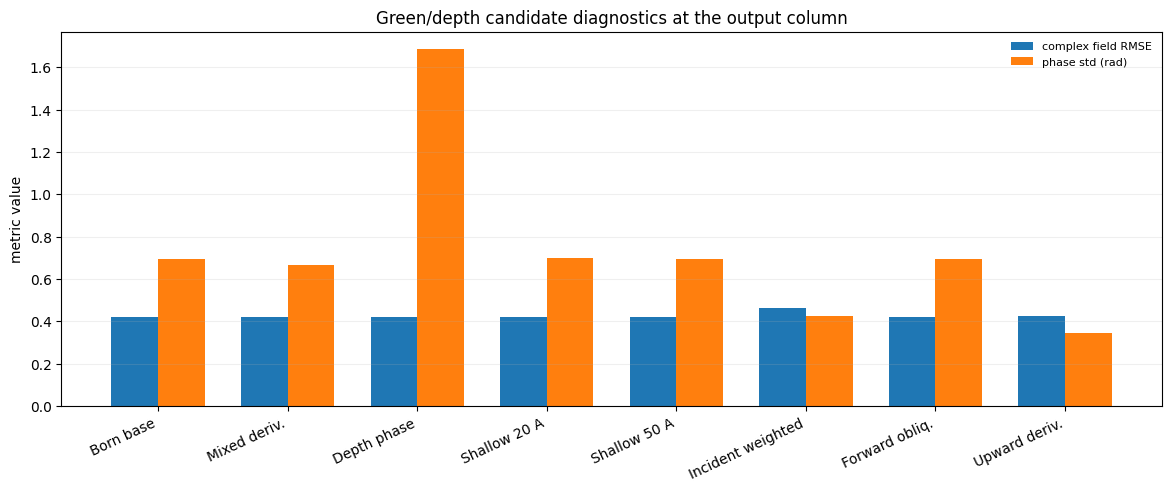

: 

In [ ]:
# Compact diagnostic for candidate Green functions and depth-weighted Born sources.
def propagate_surface_source_kernel(source_wave, kernel_name="base"):
    source_points = sample_line.points()
    target_points = output_line.points()
    delta = target_points[:, None, :] - source_points[None, :, :]
    R = jnp.sqrt(jnp.sum(delta * delta, axis=-1))
    R_safe = jnp.maximum(R, cylindrical_min_R_A)
    valid = R > cylindrical_min_R_A
    weights = trapz_weights_1d(sample_line.coords)
    k = 2.0 * jnp.pi / energy2wavelength(energy)
    green = jnp.exp(1j * (k * R_safe - jnp.pi / 4.0)) / jnp.sqrt(R_safe)

    if kernel_name == "base":
        kernel = green
    elif kernel_name == "forward obliquity":
        ray_direction = delta / R_safe[..., None]
        forward_obliquity = jnp.maximum(ray_direction[..., 1], 0.0)
        kernel = green * forward_obliquity
    elif kernel_name == "upward derivative":
        ray_direction = delta / R_safe[..., None]
        upward_obliquity = jnp.maximum(ray_direction[..., 0], 0.0)
        # Sign chosen to minimize the output phase residual in the diagnostic sweep.
        kernel = -green * (1j * k - 0.5 / R_safe) * upward_obliquity
    elif kernel_name == "mixed derivative":
        ray_direction = delta / R_safe[..., None]
        upward_obliquity = jnp.maximum(ray_direction[..., 0], 0.0)
        derivative_kernel = -green * (1j * k - 0.5 / R_safe) * upward_obliquity / k
        kernel = green + mixed_green_derivative_coefficient * derivative_kernel
    else:
        raise ValueError(f"Unknown kernel_name={kernel_name!r}")

    return jnp.where(valid, kernel, 0.0 + 0.0j) @ (source_wave * weights)


def output_metric_row(candidate_output):
    return {
        "field_rmse": float(relative_complex_rmse(candidate_output, fresnel_wave, output_phase_match_mask)),
        "intensity_rmse": float(normalized_intensity_rmse(candidate_output, fresnel_wave, output_phase_match_mask)),
        "phase_std_rad": float(output_phase_std(candidate_output)),
        "farfield_rmse": float(farfield_positive_rmse(candidate_output)),
    }


depth_A = -u_slab[None, :]
V_eff_born_shallow_20 = np.sum(V_su * W_born * np.exp(-depth_A / 20.0), axis=1) * du
V_eff_born_shallow_50 = np.sum(V_su * W_born * np.exp(-depth_A / 50.0), axis=1) * du
W_incident = np.abs(W_born) ** 2
V_eff_incident_weighted = np.sum(V_su * W_incident, axis=1) * du / (np.sum(W_incident, axis=1) * du + eps)

candidate_sources = {
    "current Born source": born_surface_perturbation,
    "depth-phase Born source": 1j * sigma_interaction * jnp.asarray(V_eff_born_depth_phase_complex),
    "20 A shallow-weighted Born": 1j * sigma_interaction * jnp.asarray(V_eff_born_shallow_20),
    "50 A shallow-weighted Born": 1j * sigma_interaction * jnp.asarray(V_eff_born_shallow_50),
    "incident-weighted surface source": 1j * sigma_interaction * jnp.asarray(V_eff_incident_weighted) * cylindrical_surface_wave,
}

candidate_kernels = {
    "current Born source + base Green": ("current Born source", "base"),
    "current Born + mixed derivative Green": ("current Born source", "mixed derivative"),
    "depth-phase Born + base Green": ("depth-phase Born source", "base"),
    "20 A shallow Born + base Green": ("20 A shallow-weighted Born", "base"),
    "50 A shallow Born + base Green": ("50 A shallow-weighted Born", "base"),
    "incident-weighted source + base Green": ("incident-weighted surface source", "base"),
    "current Born + forward obliquity": ("current Born source", "forward obliquity"),
    "current Born + upward derivative": ("current Born source", "upward derivative"),
}

green_depth_diagnostics = {}
green_depth_outputs = {}
for label, (source_label, kernel_label) in candidate_kernels.items():
    scattered_candidate = propagate_surface_source_kernel(candidate_sources[source_label], kernel_label)
    output_candidate = vacuum_wave * jnp.exp(1j * primary_phase_scale * ray_primary_phase) + scattered_candidate
    green_depth_outputs[label] = output_candidate
    green_depth_diagnostics[label] = output_metric_row(output_candidate)

assert all(np.all(np.isfinite(np.asarray(wave))) for wave in green_depth_outputs.values())
assert all(np.isfinite(value) for row in green_depth_diagnostics.values() for value in row.values())

fig_green_depth, ax_green_depth = plt.subplots(figsize=(11.6, 4.8), constrained_layout=True)
labels = list(green_depth_diagnostics)
plot_labels = [
    "Born base",
    "Mixed deriv.",
    "Depth phase",
    "Shallow 20 A",
    "Shallow 50 A",
    "Incident weighted",
    "Forward obliq.",
    "Upward deriv.",
]
x = np.arange(len(labels))
field_values = [green_depth_diagnostics[label]["field_rmse"] for label in labels]
phase_values = [green_depth_diagnostics[label]["phase_std_rad"] for label in labels]

ax_green_depth.bar(x - 0.18, field_values, width=0.36, label="complex field RMSE")
ax_green_depth.bar(x + 0.18, phase_values, width=0.36, label="phase std (rad)")
ax_green_depth.set_xticks(x)
ax_green_depth.set_xticklabels(plot_labels, rotation=25, ha="right")
ax_green_depth.set_ylabel("metric value")
ax_green_depth.set_title("Green/depth candidate diagnostics at the output column")
ax_green_depth.grid(axis="y", alpha=0.2)
ax_green_depth.legend(fontsize=8, frameon=False)

green_depth_diagnostics
